LOAN APPROVAL PROJECT

In [1]:
#Load Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


In [62]:
#LOAD DATASET
loan_approval_data = pd.read_csv("datasets/loan_approval_dataset.csv")


In [3]:
#Check data head(i.e first 5 rows of data)
loan_approval_data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
#Check total numbers of rows and columns
loan_approval_data.shape

(4269, 13)

In [5]:
#Check total numbers of columns, data types and null entries 
loan_approval_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [6]:
#Check if data has null values
loan_approval_data.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [7]:
#Check duplicates
loan_approval_data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4264    False
4265    False
4266    False
4267    False
4268    False
Length: 4269, dtype: bool

In [8]:
#Identify Column Types

cat_col = [col for col in loan_approval_data.columns if loan_approval_data[col].dtype == 'object']
num_col = [col for col in loan_approval_data.columns if loan_approval_data[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: [' education', ' self_employed', ' loan_status']
Numerical columns: ['loan_id', ' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']


In [9]:
#Drop the loan ID
loan_approval_data.drop("loan_id", axis=1, inplace=True)

In [10]:
#list out all the column to see if there is any hidden space
print(loan_approval_data.columns.tolist())

[' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [63]:
#Strip all spaces
loan_approval_data.columns = loan_approval_data.columns.str.strip()

for col in loan_approval_data.select_dtypes(include="object").columns:
    loan_approval_data[col] = loan_approval_data[col].str.strip()

In [64]:
#Verify columns to see if there is any hidden space
print(loan_approval_data.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


EXPLORATORY DATA ANALYSIS

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


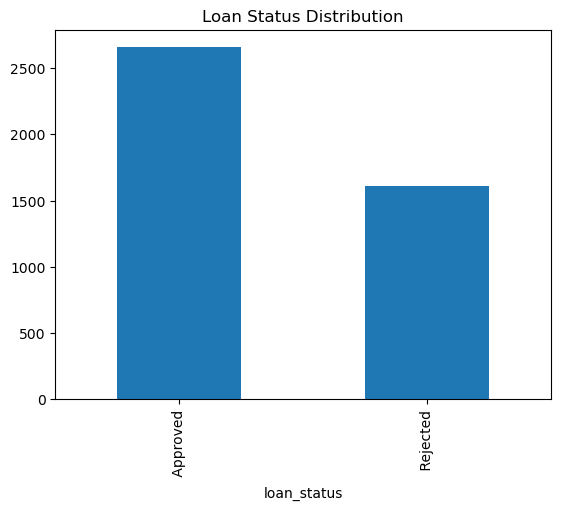

In [13]:
#1. Visualize Target variable distribution (Approved or Rejected)

print(loan_approval_data["loan_status"].value_counts())
loan_approval_data['loan_status'].value_counts().plot(kind="bar")
plt.title("Loan Status Distribution")
plt.show()

The chat above shows the class is not perfectly balaced (Mild balance). The ration is rougly 62% vs 38%

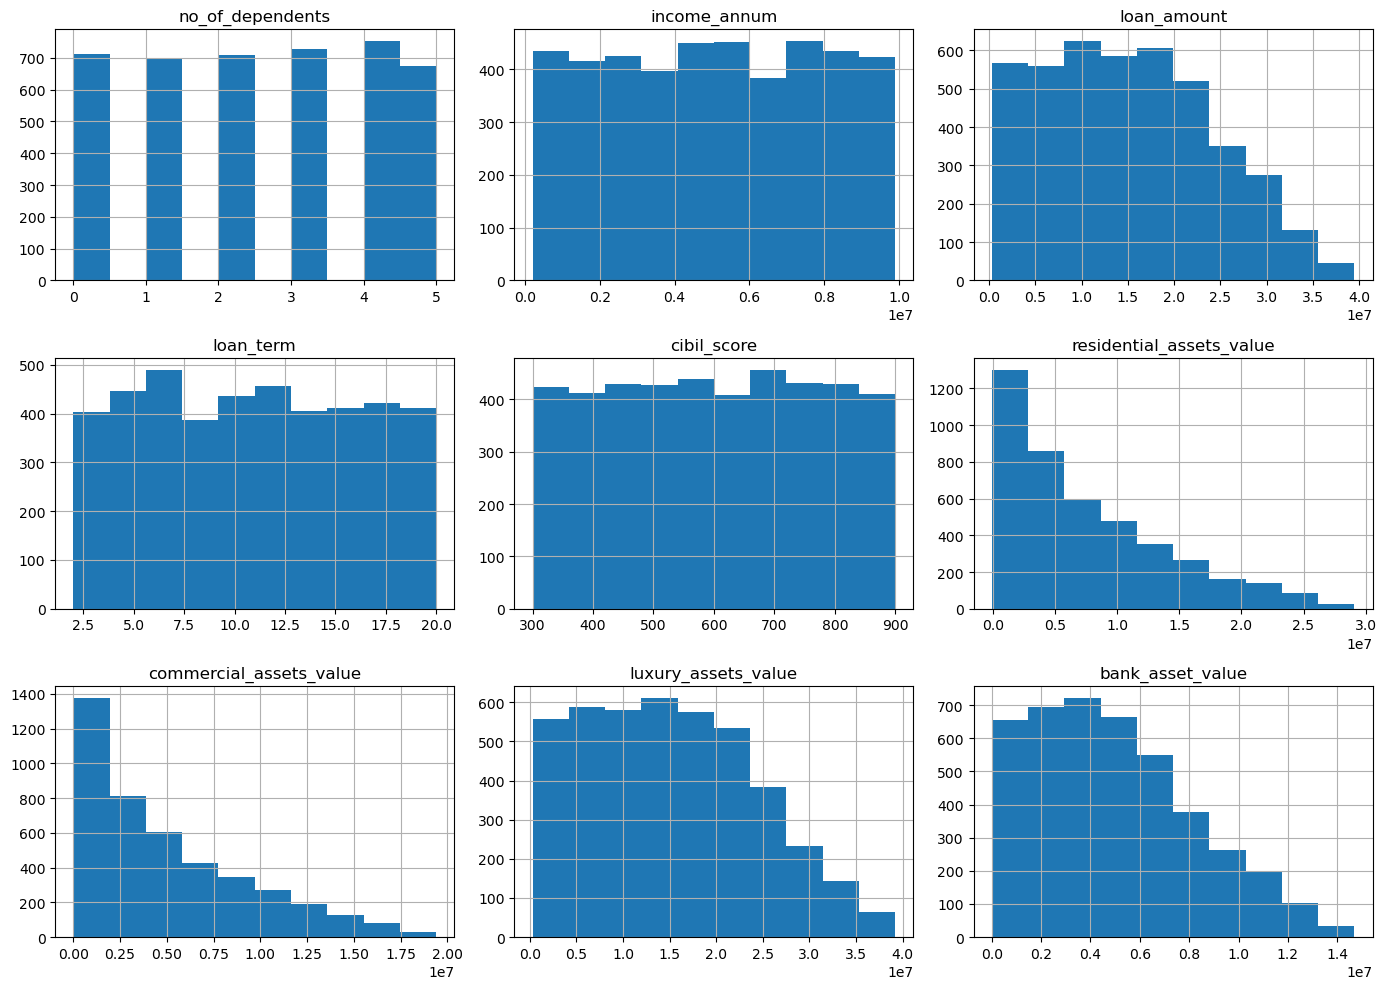

In [14]:
#2. Visualize numerical columns
#Check distribution of individual columns

loan_approval_data.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

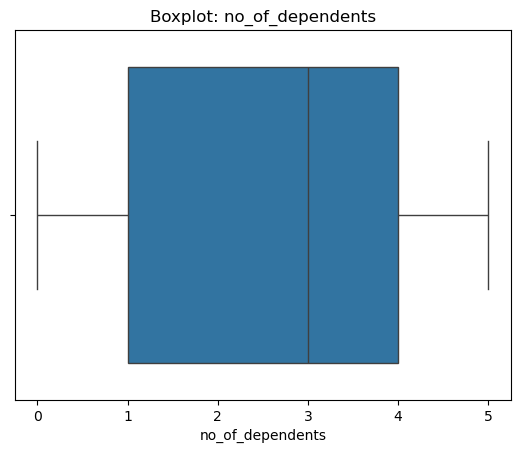

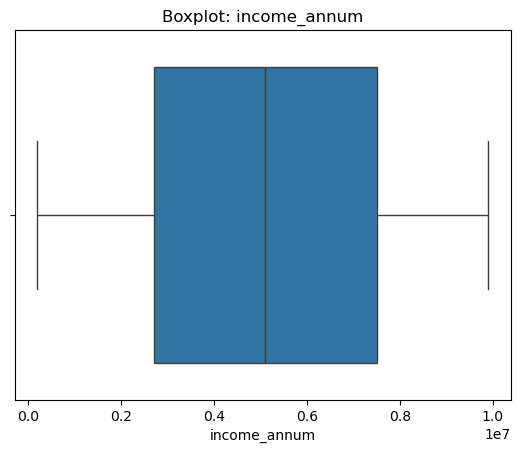

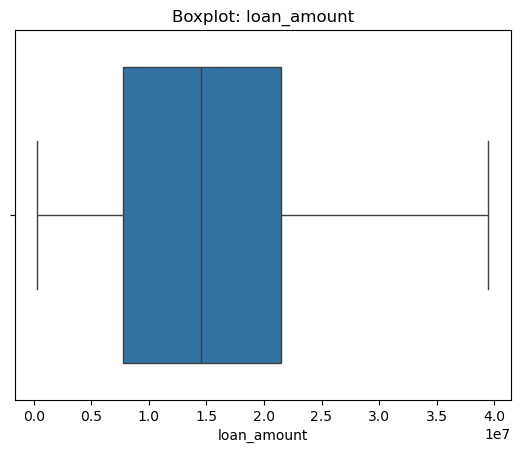

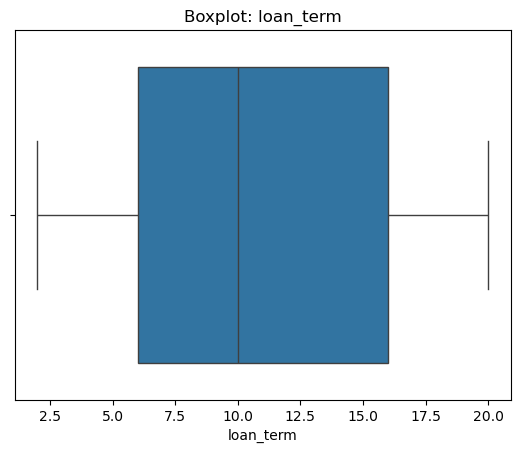

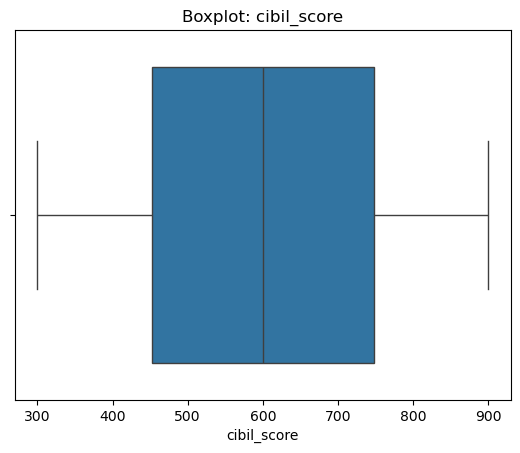

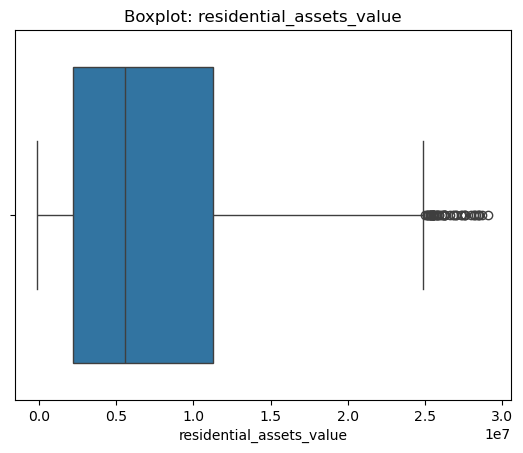

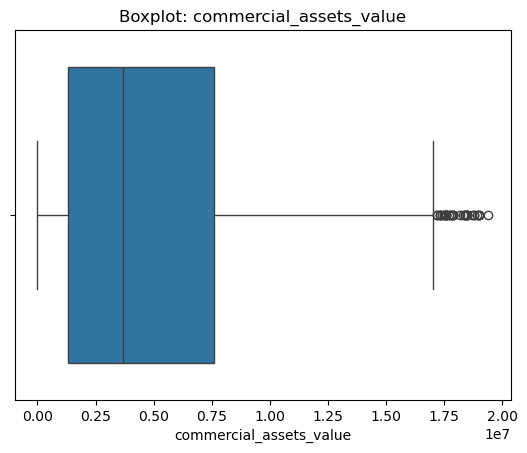

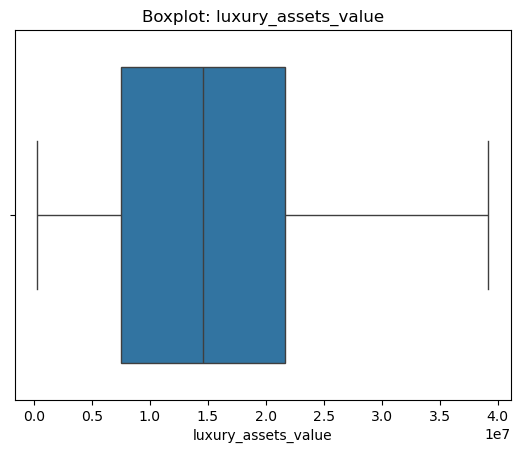

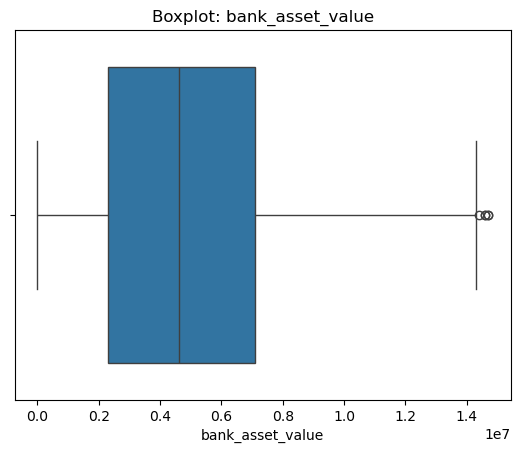

In [15]:
#3. Check outliers in our numerical columns using boxplots

numerical_cols = [
    "no_of_dependents", "income_annum", "loan_amount",
    "loan_term", "cibil_score", "residential_assets_value", "commercial_assets_value",
    "luxury_assets_value", "bank_asset_value"
]

for col in numerical_cols:
    sns.boxplot(x=loan_approval_data[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

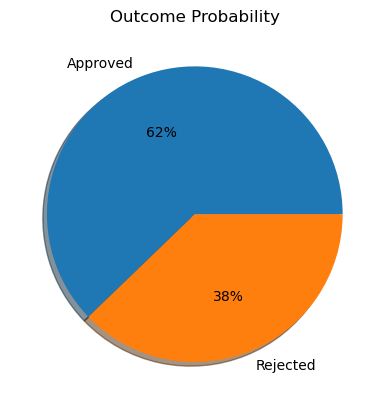

In [16]:
#4. Loan Status Distribution
counts = loan_approval_data["loan_status"].value_counts()

plt.pie(counts.values,
       labels=["Approved", "Rejected"],
       autopct="%.f%%",
       shadow=True)
plt.title("Outcome Probability")
plt.show()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

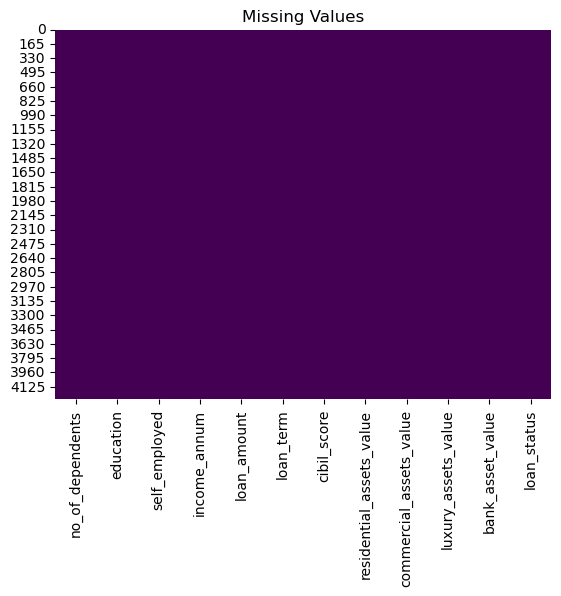

In [17]:
#5. Counting and visualizing missing values

print(loan_approval_data.isnull().sum())  #Count missing values
print(loan_approval_data.isnull().sum() * 100) #Percentage missing

sns.heatmap(loan_approval_data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show

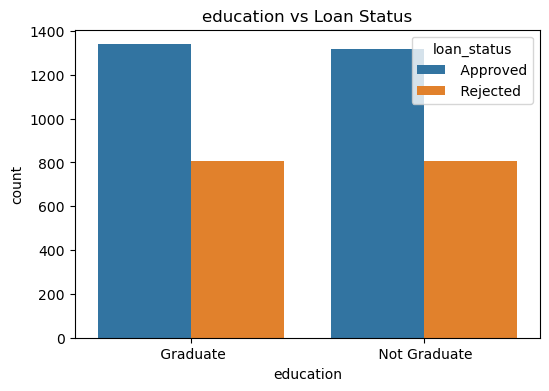

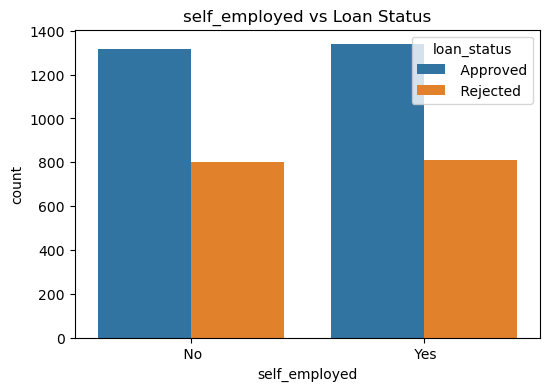

In [18]:
#6. Categotical features vs Loan Status
cat_cols = ["education", "self_employed"]

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="loan_status", data=loan_approval_data)
    plt.title(f"{col} vs Loan Status")
    plt.tight_layout
    plt.show()

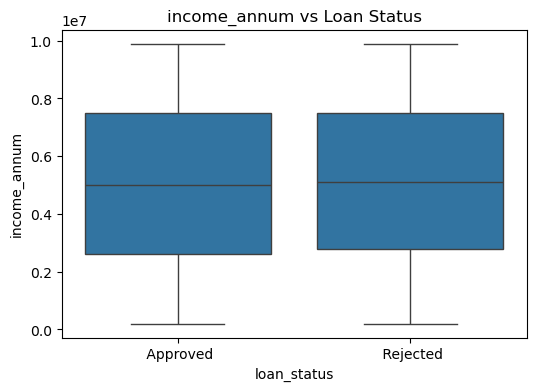

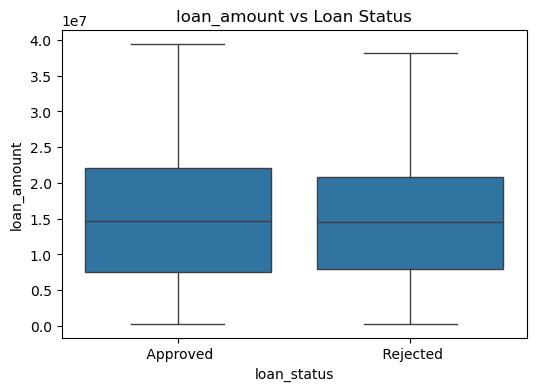

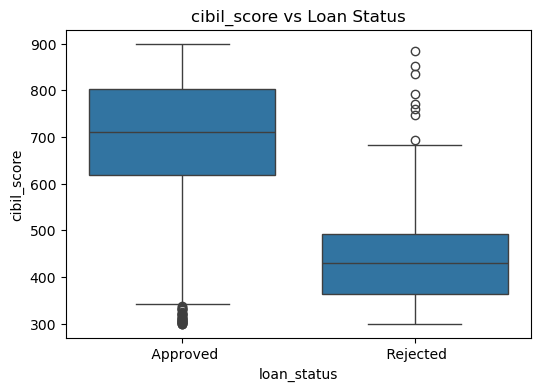

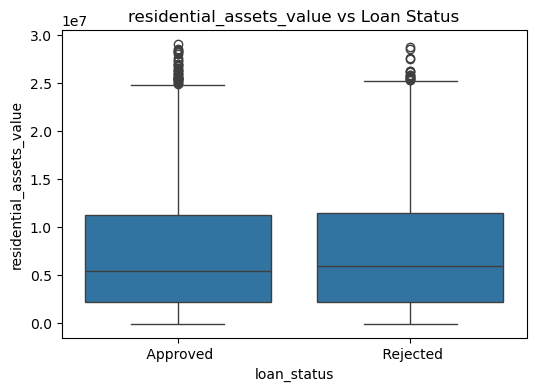

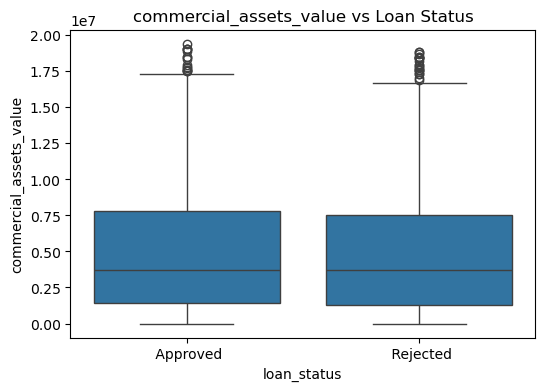

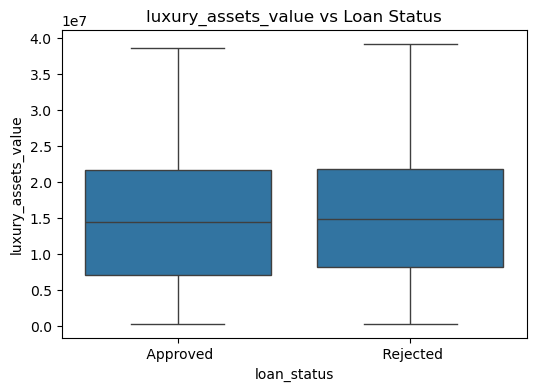

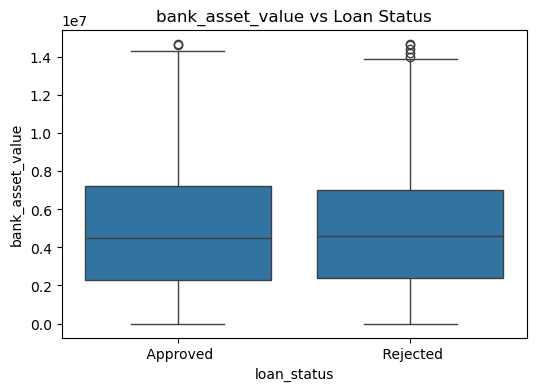

In [19]:
#6. Numerical Features vs Loan Status
num_cols = ["income_annum", "loan_amount", "cibil_score",
           "residential_assets_value", "commercial_assets_value",
           "luxury_assets_value", "bank_asset_value"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="loan_status", y=col, data=loan_approval_data)
    plt.title(f"{col} vs Loan Status")
    plt.show()

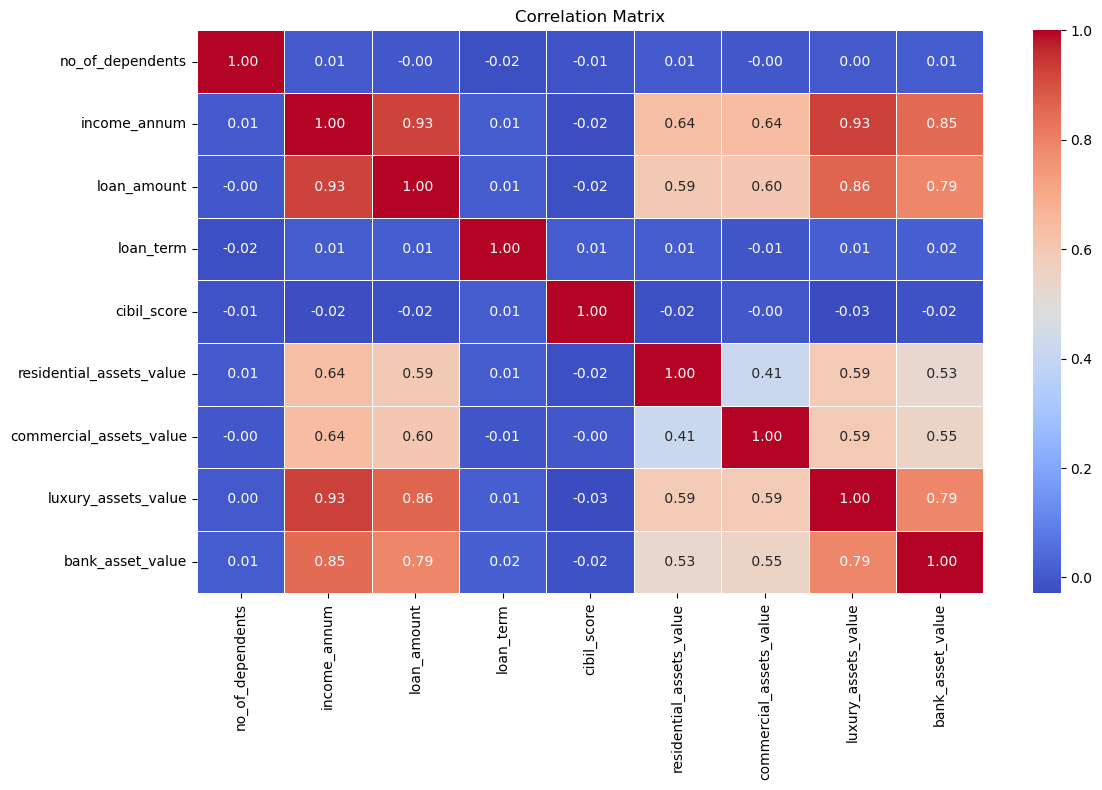

In [20]:
#7. Correlation heatmap
#Features that most influence loan approval

plt.figure(figsize=(12, 8))
corr = loan_approval_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=" .2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

FEATURE ENGINEERING AND PREPROCESSING

In [65]:
#1. Drop weak features
cols_to_drop = ["education", "self_employed", "no_of_dependents", "loan_term"]
loan_approval_data = loan_approval_data.drop(columns=cols_to_drop)

print(loan_approval_data.columns.tolist())  #Verify

['loan_id', 'income_annum', 'loan_amount', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [66]:
#2. Feature Engineering
#Create meaninful features from existing ones

#Income to loan ratio: Can you afford this loan?
loan_approval_data["income_to_loan_ratio"] = (loan_approval_data["income_annum"] / loan_approval_data["loan_amount"])

#Total assets combined
loan_approval_data["total_assets"] = (loan_approval_data["residential_assets_value"] +
                                     loan_approval_data["commercial_assets_value"] +
                                     loan_approval_data["luxury_assets_value"] +
                                     loan_approval_data["bank_asset_value"]
)

#Assets to loan ratio: Do you have enough backing
loan_approval_data["assets_to_loan_ratio"] = (loan_approval_data["total_assets"] / loan_approval_data["loan_amount"]
)


In [67]:
#Checking the column
print(loan_approval_data["loan_status"].unique())
print(loan_approval_data["loan_status"].dtype)

['Approved' 'Rejected']
object


In [68]:
#Encoding the Loan Status column
loan_approval_data["loan_status"] = loan_approval_data["loan_status"].str.strip()   #Stripping the spaces

loan_approval_data["loan_status"] = loan_approval_data["loan_status"].map(
    {"Approved": 1, "Rejected": 0}
)

#Verify
print(loan_approval_data["loan_status"].unique())

[1 0]


In [69]:
#3. Separating Features and Targets

X = loan_approval_data.drop(columns=["loan_status"])
y = loan_approval_data["loan_status"]

print(X.shape)
print(y.value_counts())

(4269, 11)
loan_status
1    2656
0    1613
Name: count, dtype: int64


In [70]:
#4. Test/Train Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Training size: (2988, 11)
Test size: (1281, 11)


In [71]:
#5. Scaling Numerical Features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


MODEL TRAINING

In [74]:
#We are going to train 3 models for comparison

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

In [73]:
#Model 1: Logistic Regession (Baseline)
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

#Model 2: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

#Model 3: XGBoost
xgb_model = xgb.XGBClassifier(n_estimator=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

print("All models trained successfully!")

All models trained successfully!


/opt/anaconda3/envs/xgb64/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [07:34:29] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1767713757252/work/src/learner.cc:790: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MODEL EVALUATION

In [76]:
#Accuracy Comparison

models = {
    "logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


--- logistic Regression ---
Accuracy: 0.9118
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       471
           1       0.94      0.92      0.93       810

    accuracy                           0.91      1281
   macro avg       0.90      0.91      0.91      1281
weighted avg       0.91      0.91      0.91      1281


--- Random Forest ---
Accuracy: 0.9524
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       471
           1       1.00      0.93      0.96       810

    accuracy                           0.95      1281
   macro avg       0.94      0.96      0.95      1281
weighted avg       0.96      0.95      0.95      1281


--- XGBoost ---
Accuracy: 0.9454
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       471
           1       0.98      0.93      0.96       810

    accuracy                           0.95      1281
   macro

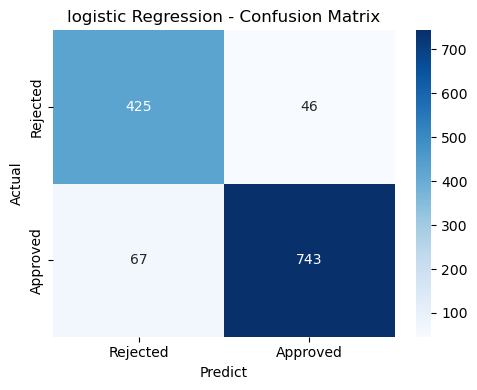

Saved: logistic_Regression_Cofusion_Matrix.png


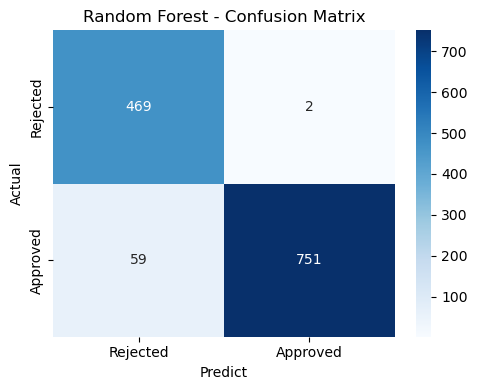

Saved: Random_Forest_Cofusion_Matrix.png


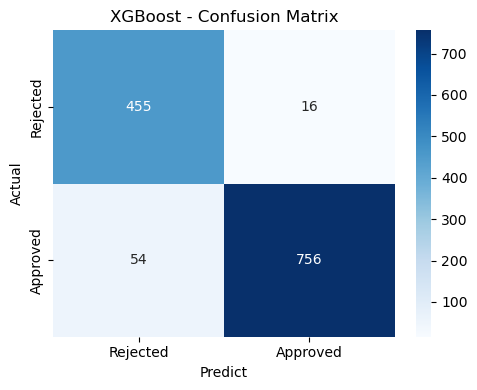

Saved: XGBoost_Cofusion_Matrix.png


In [80]:
#Confusion Matrix for each model

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
               xticklabels=["Rejected", "Approved"],
               yticklabels=["Rejected", "Approved"])
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predict")
    plt.tight_layout()

    clean_name = name.replace(" ", "_")
    filename = f"{clean_name}_Cofusion_Matrix.png"
    
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Saved: {filename}")


MODEL SAVING

In [83]:
#Saving the best model and scaler
import joblib

joblib.dump(rf_model, "best_model_random_forest.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
